In [6]:
# ============================================================
# CONFIG
# ============================================================

# Folder containing the extracted contents of GSE157827_RAW.tar

# ============================================================
# GSE157827 -> Combined AnnData -> VAE-ready matrix -> mtVAE train
# ============================================================
#
# What this script does:
# 1. Finds all 10x sample triplets in RAW_DIR
# 2. Loads them into one combined AnnData object
# 3. Preserves raw counts in adata.layers["counts"]
# 4. Normalizes/log-transforms data for VAE input
# 5. Optionally restricts to highly variable genes
# 6. Splits into train/validation sets
# 7. Trains the mtVAE
# 8. Saves:
#    - combined .h5ad
#    - train/val .npy matrices
#    - latent embeddings
#    - trained VAE / encoder / decoder
#
# Notes:
# - This script assumes your raw files are extracted from GSE157827_RAW.tar
# - The VAE takes a dense numeric matrix of shape (n_cells, n_genes)
# - For scRNA-seq, normalized + log1p data is much more compatible with MSE loss
#
# ============================================================

In [7]:
import os
import re
import random
import shutil

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import tensorflow as tf
import keras

from keras import ops
from scipy import sparse
from pandas.api.types import is_string_dtype
from sklearn.model_selection import train_test_split

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Lambda, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [8]:
# ============================================================
# CONFIG
# ============================================================

RAW_DIR = "/Users/lauraliang/BIPN162_final/BIPN162_FinalProject/GSE157827_RAW"
OUT_DIR = "gse157827_vae_output"

COMBINED_H5AD = "GSE157827_combined.h5ad"
TRAIN_NPY = "GSE157827_X_train.npy"
VAL_NPY = "GSE157827_X_val.npy"
TRAIN_OBS_CSV = "GSE157827_train_obs.csv"
VAL_OBS_CSV = "GSE157827_val_obs.csv"
LATENT_TRAIN_NPY = "GSE157827_latent_train.npy"
LATENT_VAL_NPY = "GSE157827_latent_val.npy"

# Preprocessing
USE_HVG = True
N_TOP_GENES = 1000
MIN_CELLS_PER_GENE = 3
TARGET_SUM = 1e4

# Train/validation split
TEST_SIZE = 0.2
RANDOM_STATE = 42

# VAE hyperparameters
INTERMEDIATE_DIM = 128
LATENT_DIM = 16
KL_BETA = 1e-4
LEARNING_RATE = 1e-3
N_EPOCHS = 100
BATCH_SIZE = 128
VERBOSITY = 2

# Reproducibility
SEED = 42



In [9]:
# %%
print("Current N_TOP_GENES:", N_TOP_GENES)
print("Current USE_HVG:", USE_HVG)

adata_combined = ad.read_h5ad(os.path.join(OUT_DIR, COMBINED_H5AD))



Current N_TOP_GENES: 1000
Current USE_HVG: True


In [10]:
# ============================================================
# HELPERS
# ============================================================

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def ensure_out_dir(out_dir: str) -> None:
    os.makedirs(out_dir, exist_ok=True)


def sanitize_for_h5ad_write(adata: ad.AnnData) -> ad.AnnData:
    """
    Convert nullable/object/string-heavy columns to safer string dtype
    so AnnData writes cleanly to h5ad.
    """
    adata = adata.copy()

    for df_name in ["obs", "var"]:
        df = getattr(adata, df_name)
        for col in df.columns:
            if is_string_dtype(df[col]) or df[col].dtype == "object":
                df[col] = df[col].astype(str)
        setattr(adata, df_name, df)

    return adata


def find_10x_triplets(raw_dir: str):
    """
    Find matching barcode / feature / matrix file triplets.
    Assumes filenames contain a shared sample prefix and one of:
      - barcodes
      - features
      - matrix
    """
    files = os.listdir(raw_dir)

    barcode_files = [f for f in files if "barcode" in f.lower()]
    feature_files = [f for f in files if "feature" in f.lower()]
    matrix_files = [f for f in files if "matrix" in f.lower()]

    def sample_key(fname: str) -> str:
        lower = fname.lower()
        lower = re.sub(r"barcodes?", "", lower)
        lower = re.sub(r"features?", "", lower)
        lower = re.sub(r"matrix", "", lower)
        lower = re.sub(r"\.tsv(\.gz)?$", "", lower)
        lower = re.sub(r"\.mtx(\.gz)?$", "", lower)
        lower = re.sub(r"[_\-.]+$", "", lower)
        return lower

    barcode_map = {sample_key(f): f for f in barcode_files}
    feature_map = {sample_key(f): f for f in feature_files}
    matrix_map = {sample_key(f): f for f in matrix_files}

    common_keys = sorted(set(barcode_map) & set(feature_map) & set(matrix_map))

    triplets = []
    for key in common_keys:
        triplets.append(
            {
                "sample_id": key,
                "barcodes": os.path.join(raw_dir, barcode_map[key]),
                "features": os.path.join(raw_dir, feature_map[key]),
                "matrix": os.path.join(raw_dir, matrix_map[key]),
            }
        )

    if len(triplets) == 0:
        raise FileNotFoundError(
            f"No 10x triplets found in {raw_dir}. Check filenames and extraction."
        )

    return triplets


def read_10x_triplet(barcodes_path: str, features_path: str, matrix_path: str) -> ad.AnnData:
    """
    Load one 10x-style triplet into AnnData.
    """
    # Read matrix
    X = sc.read_mtx(matrix_path).X.T  # transpose to cells x genes

    # Read barcodes
    barcodes = pd.read_csv(barcodes_path, header=None, sep="\t")
    obs = pd.DataFrame(index=barcodes.iloc[:, 0].astype(str).values)

    # Read features
    features = pd.read_csv(features_path, header=None, sep="\t")
    if features.shape[1] >= 2:
        var_names = features.iloc[:, 1].astype(str).values
        gene_ids = features.iloc[:, 0].astype(str).values
    else:
        var_names = features.iloc[:, 0].astype(str).values
        gene_ids = features.iloc[:, 0].astype(str).values

    var = pd.DataFrame(index=var_names)
    var["gene_id"] = gene_ids

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.var_names_make_unique()
    return adata


def build_combined_adata(raw_dir: str) -> ad.AnnData:
    """
    Build one combined AnnData from all detected 10x triplets.
    """
    triplets = find_10x_triplets(raw_dir)
    adatas = []

    print(f"Found {len(triplets)} sample triplets.")

    for triplet in triplets:
        print(f"Loading sample: {triplet['sample_id']}")
        adata_i = read_10x_triplet(
            triplet["barcodes"],
            triplet["features"],
            triplet["matrix"],
        )

        adata_i.obs["sample_id"] = triplet["sample_id"]
        adata_i.obs_names = [f"{triplet['sample_id']}_{bc}" for bc in adata_i.obs_names]
        adatas.append(adata_i)

    adata = ad.concat(adatas, join="outer", label="batch", keys=[a.obs["sample_id"].iloc[0] for a in adatas])
    adata.var_names_make_unique()
    return adata


def preprocess_for_vae(
    adata: ad.AnnData,
    use_hvg: bool = True,
    n_top_genes: int = 2000,
    min_cells_per_gene: int = 3,
    target_sum: float = 1e4,
):
    """
    Preprocess scRNA-seq data into a dense, VAE-ready matrix.
    Returns:
      - processed AnnData
      - dense numpy array X (cells x genes), float32
    """
    adata = adata.copy()

    # Preserve raw counts if available
    adata.layers["counts"] = adata.X.copy()

    # Basic filtering
    sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)

    # Normalize + log1p
    sc.pp.normalize_total(adata, target_sum=target_sum)
    sc.pp.log1p(adata)

    # HVG selection
    if use_hvg:
        sc.pp.highly_variable_genes(
            adata,
            n_top_genes=n_top_genes,
            flavor="seurat",
        )
        adata = adata[:, adata.var["highly_variable"]].copy()

    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()

    X = np.asarray(X, dtype=np.float32)

    if np.isnan(X).any() or np.isinf(X).any():
        raise ValueError("X contains NaN or inf after preprocessing.")

    return adata, X


def split_data(
    X: np.ndarray,
    obs: pd.DataFrame,
    test_size: float = 0.15,
    random_state: int = 42,
):
    """
    Split matrix and matching obs table into train/val.
    """
    idx = np.arange(X.shape[0])

    train_idx, val_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
    )

    X_train = X[train_idx].astype(np.float32)
    X_val = X[val_idx].astype(np.float32)

    obs_train = obs.iloc[train_idx].copy()
    obs_val = obs.iloc[val_idx].copy()

    return X_train, X_val, obs_train, obs_val


In [11]:
class Sampling(tf.keras.layers.Layer):
    def __init__(self, kl_beta=1e-2, **kwargs):
        super().__init__(**kwargs)
        self.kl_beta = kl_beta

    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        z = mu + tf.exp(0.5 * log_var) * eps

        kl_loss = -0.5 * tf.reduce_sum(
            1 + log_var - tf.square(mu) - tf.exp(log_var),
            axis=1
        )
        self.add_loss(self.kl_beta * tf.reduce_mean(kl_loss))
        return z


class mtVAE:
    def __init__(
        self,
        input_shape,
        intermediate_dim,
        latent_dim,
        kl_beta=1e-2,
        learning_rate=1e-3,
    ):
        self.input_shape = input_shape
        self.intermediate_dim = intermediate_dim
        self.latent_dim = latent_dim
        self.kl_beta = kl_beta
        self.learning_rate = learning_rate

        # Encoder
        self.input = Input(shape=(self.input_shape,), name="encoder_input")
        x = Dense(self.intermediate_dim)(self.input)
        x = LeakyReLU()(x)

        self.mu = Dense(self.latent_dim, name="latent_mu")(x)
        self.log_var = Dense(self.latent_dim, name="latent_log_var")(x)
        self.z = Sampling(kl_beta=self.kl_beta, name="z")([self.mu, self.log_var])

        self.encoder = Model(
            self.input,
            [self.mu, self.log_var, self.z],
            name="encoder",
        )

        # Decoder
        self.decoder_input = Input(shape=(self.latent_dim,), name="decoder_input")
        x = Dense(self.intermediate_dim)(self.decoder_input)
        x = LeakyReLU()(x)
        self.output = Dense(self.input_shape)(x)

        self.decoder = Model(self.decoder_input, self.output, name="decoder")

        # Full VAE
        self.vae_outputs = self.decoder(self.z)
        self.vae = Model(self.input, self.vae_outputs, name="vae")

        self.optimizer = Adam(learning_rate=self.learning_rate)
        self.vae.compile(
            optimizer=self.optimizer,
            loss="mse",
            metrics=["mse"],
        )

    def train(self, train_data, val_data, n_epochs, batch_size, verbosity=2):
        train_data = np.asarray(train_data).astype(np.float32)
        val_data = np.asarray(val_data).astype(np.float32)

        self.vae.fit(
            train_data,
            train_data,
            epochs=n_epochs,
            batch_size=batch_size,
            validation_data=(val_data, val_data),
            verbose=verbosity,
        )

    def encode(self, data):
        data = np.asarray(data).astype(np.float32)
        return self.encoder.predict(data)

    def encode_z(self, data):
        return self.encode(data)[2]

    def encode_mu(self, data):
        return self.encode(data)[0]

    def decode(self, data):
        data = np.asarray(data).astype(np.float32)
        return self.decoder.predict(data)

    def reconstruct(self, data):
        return self.decode(self.encode_z(data))

    def save_model(self, save_folder):
        os.makedirs(save_folder, exist_ok=True)

        self.vae.save(os.path.join(save_folder, "VAE.keras"))
        self.encoder.save(os.path.join(save_folder, "VAE_encoder.keras"))
        self.decoder.save(os.path.join(save_folder, "VAE_decoder.keras"))


In [12]:
# ============================================================
# MAIN
# ============================================================

def main():
    set_seed(SEED)
    ensure_out_dir(OUT_DIR)

    # 1. Build combined AnnData
    adata = build_combined_adata(RAW_DIR)
    adata = sanitize_for_h5ad_write(adata)

    combined_h5ad_path = os.path.join(OUT_DIR, COMBINED_H5AD)
    with ad.settings.override(allow_write_nullable_strings=True):
        adata.write_h5ad(combined_h5ad_path)
    print(f"\nSaved combined AnnData to: {combined_h5ad_path}")

    # 2. Preprocess into VAE-ready matrix
    adata_vae, X = preprocess_for_vae(
        adata,
        use_hvg=USE_HVG,
        n_top_genes=N_TOP_GENES,
        min_cells_per_gene=MIN_CELLS_PER_GENE,
        target_sum=TARGET_SUM,
    )

    # 3. Split into train / validation
    X_train, X_val, obs_train, obs_val = split_data(
        X,
        adata_vae.obs,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    print("\nTrain shape:", X_train.shape)
    print("Val shape:", X_val.shape)

    # Safety checks
    print("Train dtype:", X_train.dtype)
    print("Val dtype:", X_val.dtype)
    print("NaNs in train:", np.isnan(X_train).sum())
    print("NaNs in val:", np.isnan(X_val).sum())
    print("Infs in train:", np.isinf(X_train).sum())
    print("Infs in val:", np.isinf(X_val).sum())

    # 4. Save train/val matrices + metadata
    np.save(os.path.join(OUT_DIR, TRAIN_NPY), X_train)
    np.save(os.path.join(OUT_DIR, VAL_NPY), X_val)
    obs_train.to_csv(os.path.join(OUT_DIR, TRAIN_OBS_CSV))
    obs_val.to_csv(os.path.join(OUT_DIR, VAL_OBS_CSV))

    print("\nSaved train/val matrices and metadata.")

    # 5. Build and train VAE
    vae = mtVAE(
        input_shape=X_train.shape[1],
        intermediate_dim=INTERMEDIATE_DIM,
        latent_dim=LATENT_DIM,
        kl_beta=KL_BETA,
        learning_rate=LEARNING_RATE,
    )

    print("\nTraining VAE...")
    vae.train(
        train_data=X_train,
        val_data=X_val,
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        verbosity=VERBOSITY,
    )

    # 6. Save model
    model_dir = os.path.join(OUT_DIR, "model")
    vae.save_model(model_dir)
    print(f"\nSaved VAE model files to: {model_dir}")

    # 7. Save latent embeddings
    z_train = vae.encode_z(X_train)
    z_val = vae.encode_z(X_val)

    np.save(os.path.join(OUT_DIR, LATENT_TRAIN_NPY), z_train)
    np.save(os.path.join(OUT_DIR, LATENT_VAL_NPY), z_val)

    print("\nSaved latent embeddings.")
    print(f"Train latent shape: {z_train.shape}")
    print(f"Val latent shape:   {z_val.shape}")

    print("\nDone.")


if __name__ == "__main__":
    main()

Found 21 sample triplets.
Loading sample: gsm4775561_ad1


/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loading sample: gsm4775562_ad2


/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loading sample: gsm4775563_ad4


...

Loading sample: gsm4775581_nc18


/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")



Saved combined AnnData to: gse157827_vae_output/GSE157827_combined.h5ad


/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding



Train shape: (143513, 1000)
Val shape: (35879, 1000)
Train dtype: float32
Val dtype: float32
NaNs in train: 0
NaNs in val: 0
Infs in train: 0
Infs in val: 0

Saved train/val matrices and metadata.

Training VAE...
Epoch 1/100
1122/1122 - 6s - 5ms/step - loss: 0.1018 - mse: 0.0981 - val_loss: 0.0930 - val_mse: 0.0894
Epoch 2/100
1122/1122 - 4s - 4ms/step - loss: 0.0916 - mse: 0.0880 - val_loss: 0.0901 - val_mse: 0.0866
Epoch 3/100
1122/1122 - 4s - 4ms/step - loss: 0.0895 - mse: 0.0860 - val_loss: 0.0886 - val_mse: 0.0851
Epoch 4/100
1122/1122 - 4s - 4ms/step - loss: 0.0884 - mse: 0.0849 - val_loss: 0.0878 - val_mse: 0.0843
Epoch 5/100
1122/1122 - 4s - 4ms/step - loss: 0.0877 - mse: 0.0841 - val_loss: 0.0872 - val_mse: 0.0837
Epoch 6/100
1122/1122 - 4s - 4ms/step - loss: 0.0871 - mse: 0.0836 - val_loss: 0.0867 - val_mse: 0.0832
Epoch 7/100
1122/1122 - 4s - 4ms/step - loss: 0.0867 - mse: 0.0832 - val_loss: 0.0864 - val_mse: 0.0829
Epoch 8/100
1122/1122 - 6s - 5ms/step - loss: 0.0864 - ms

In [13]:
import os

RAW_DIR = "/Users/lauraliang/BIPN162_final/BIPN162_FinalProject/GSE157827_RAW"

print("Exists:", os.path.exists(RAW_DIR))
print("Items in folder:")
print(os.listdir(RAW_DIR)[:20])
print("Total items:", len(os.listdir(RAW_DIR)))

Exists: True
Items in folder:
['GSM4775572_AD21_matrix.mtx.gz', 'GSM4775571_AD20_barcodes.tsv.gz', 'GSM4775575_NC11_features.tsv.gz', 'GSM4775574_NC7_barcodes.tsv.gz', 'GSM4775562_AD2_features.tsv', 'GSM4775579_NC16_matrix.mtx.gz', '.DS_Store', 'GSM4775561_AD1_features.tsv.gz', 'GSM4775563_AD4_matrix.mtx.gz', 'GSM4775578_NC15_features.tsv.gz', 'GSM4775568_AD10_matrix.mtx.gz', 'GSM4775565_AD6_features.tsv.gz', 'GSM4775569_AD13_features.tsv.gz', 'GSM4775576_NC12_barcodes.tsv.gz', 'GSM4775580_NC17_matrix.mtx.gz', 'GSM4775566_AD8_barcodes.tsv.gz', 'GSM4775567_AD9_features.tsv.gz', 'GSM4775577_NC14_barcodes.tsv.gz', 'GSM4775570_AD19_matrix.mtx.gz', 'GSM4775581_NC18_matrix.mtx.gz']
Total items: 65


In [14]:
z_train = np.load(os.path.join(OUT_DIR, LATENT_TRAIN_NPY))
z_val = np.load(os.path.join(OUT_DIR, LATENT_VAL_NPY))

print(z_train.shape)
print(z_val.shape)


(143513, 16)
(35879, 16)


In [15]:
print(OUT_DIR)

gse157827_vae_output


In [16]:
import os
os.listdir(OUT_DIR)

['GSE157827_X_train.npy',
 '.DS_Store',
 'GSE157827_latent_train.npy',
 'pca_umap_val.csv',
 'sage_values',
 'vae_vs_pca_metrics.csv',
 'vae_umap_val.csv',
 'GSE157827_val_obs.csv',
 'GSE157827_combined.h5ad',
 'model',
 'GSE157827_X_val.npy',
 'GSE157827_latent_val.npy',
 'shap_values',
 'GSE157827_train_obs.csv']

In [17]:
print(TRAIN_NPY)
print(VAL_NPY)

GSE157827_X_train.npy
GSE157827_X_val.npy


In [18]:
import numpy as np
import pandas as pd
import os

OUT_DIR = "gse157827_vae_output"

X_train = np.load(os.path.join(OUT_DIR, "GSE157827_X_train.npy"))
X_val   = np.load(os.path.join(OUT_DIR, "GSE157827_X_val.npy"))

obs_train = pd.read_csv(os.path.join(OUT_DIR, "GSE157827_train_obs.csv"), index_col=0)
obs_val   = pd.read_csv(os.path.join(OUT_DIR, "GSE157827_val_obs.csv"), index_col=0)

print(X_train.shape, X_val.shape)
print(obs_train.shape, obs_val.shape)


(143513, 1000) (35879, 1000)
(143513, 2) (35879, 2)


In [19]:
import tensorflow as tf
import os

model_dir = os.path.join(OUT_DIR, "model")

encoder = tf.keras.models.load_model(
    os.path.join(model_dir, "VAE_encoder.keras"),
    custom_objects={"Sampling": Sampling}
)

mu_train, logvar_train, z_train = encoder.predict(X_train)
mu_val, logvar_val, z_val = encoder.predict(X_val)

print(mu_train.shape, mu_val.shape)

4485/4485 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
(143513, 16) (35879, 16)


In [20]:


z_train = np.load(os.path.join(OUT_DIR, LATENT_TRAIN_NPY))
z_val = np.load(os.path.join(OUT_DIR, LATENT_VAL_NPY))

obs_train = pd.read_csv(os.path.join(OUT_DIR, TRAIN_OBS_CSV), index_col=0)
obs_val = pd.read_csv(os.path.join(OUT_DIR, VAL_OBS_CSV), index_col=0)


In [21]:
z_train_df = pd.DataFrame(z_train, index=obs_train.index)
z_val_df = pd.DataFrame(z_val, index=obs_val.index)


In [22]:
z_train_df = pd.concat([obs_train, z_train_df], axis=1)
z_val_df = pd.concat([obs_val, z_val_df], axis=1)


In [23]:
print(z_train.shape)
print(obs_train.shape)

print(z_val.shape)
print(obs_val.shape)


(143513, 16)
(143513, 2)
(35879, 16)
(35879, 2)


/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_train shape: (143513, 1000)
X_val shape:   (35879, 1000)
obs_train shape: (143513, 2)
obs_val shape:   (35879, 2)

Condition counts (validation):
condition
AD    19070
NC    16809
Name: count, dtype: int64

VAE latent shapes:
mu_train: (143513, 16)
mu_val:   (35879, 16)

PCA latent shapes:
pca_train: (143513, 16)
pca_val:   (35879, 16)

Held-out reconstruction MSE
PCA: 0.091526
VAE: 0.078455

Correlation analysis
Genes kept: 950
Genes removed: 50

Correlation-matrix MSE
PCA: 0.117303
VAE: 0.040370

Summary:


,model,reconstruction_mse,correlation_mse
0,PCA,0.091526,0.117303
1,VAE,0.078455,0.040370


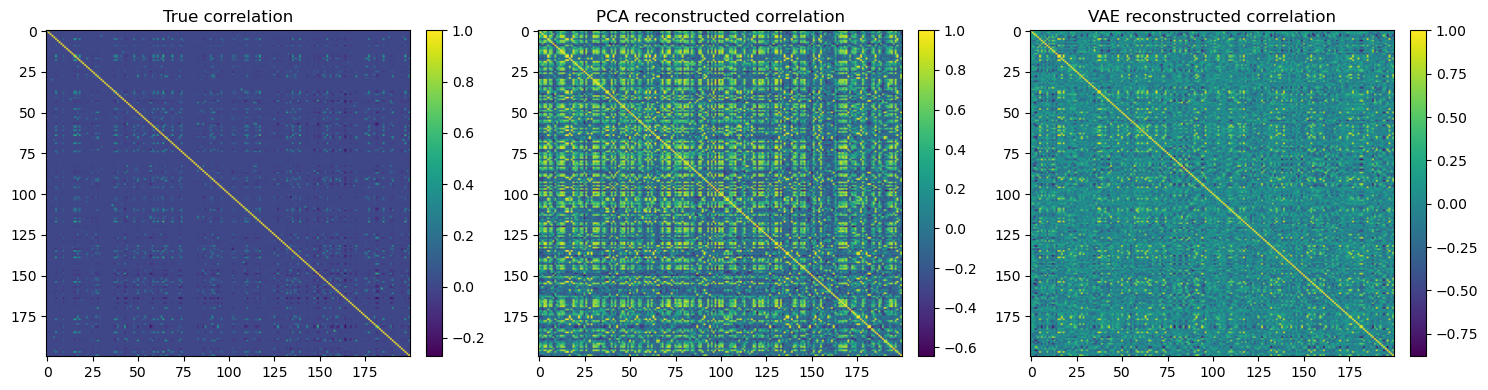

/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


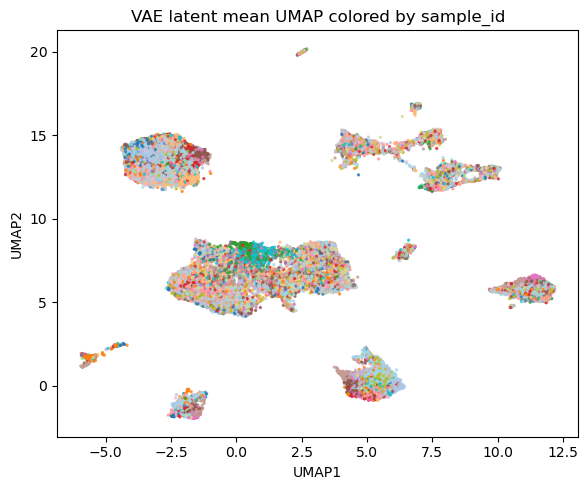

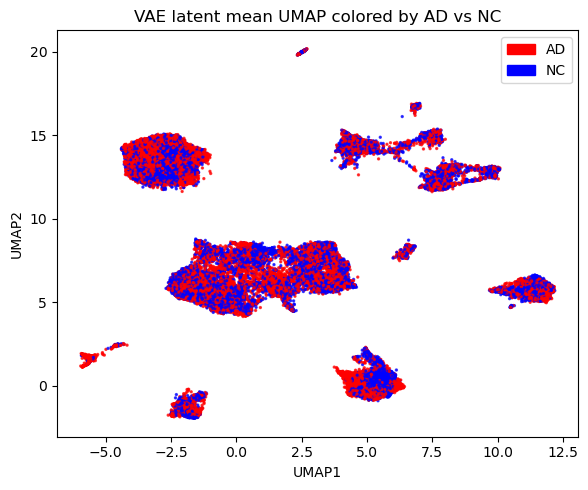

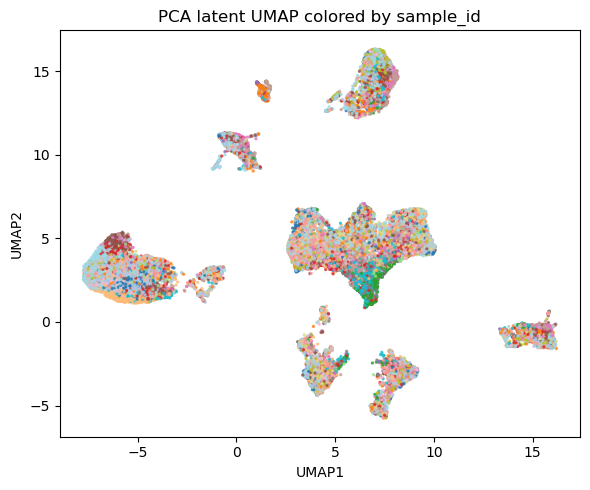

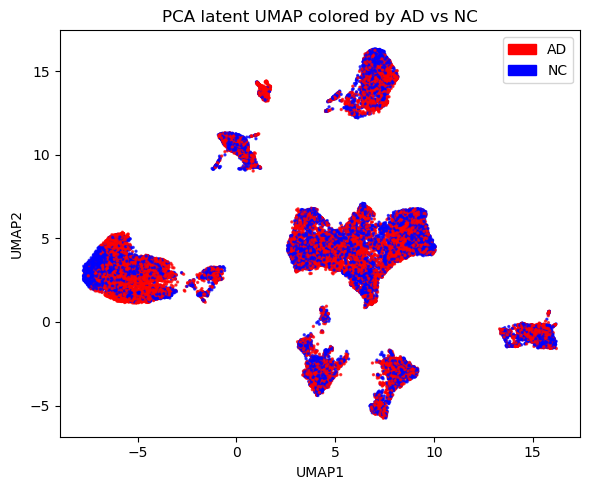

In [24]:
# ============================================================
# EVALUATION SCRIPT: VAE vs PCA on held-out validation data
# Assumes the VAE has already been trained and saved.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
import umap

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
OUT_DIR = "gse157827_vae_output"
MODEL_DIR = os.path.join(OUT_DIR, "model")

TRAIN_NPY = "GSE157827_X_train.npy"
VAL_NPY = "GSE157827_X_val.npy"
TRAIN_OBS_CSV = "GSE157827_train_obs.csv"
VAL_OBS_CSV = "GSE157827_val_obs.csv"
LATENT_TRAIN_NPY = "GSE157827_latent_train.npy"
LATENT_VAL_NPY = "GSE157827_latent_val.npy"

# Use the same latent dimension you trained the VAE with
LATENT_DIM = 16
RANDOM_STATE = 42

# ------------------------------------------------------------
# LOAD SAVED DATA
# ------------------------------------------------------------
X_train = np.load(os.path.join(OUT_DIR, TRAIN_NPY)).astype("float32")
X_val   = np.load(os.path.join(OUT_DIR, VAL_NPY)).astype("float32")

obs_train = pd.read_csv(os.path.join(OUT_DIR, TRAIN_OBS_CSV), index_col=0)
obs_val   = pd.read_csv(os.path.join(OUT_DIR, VAL_OBS_CSV), index_col=0)

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("obs_train shape:", obs_train.shape)
print("obs_val shape:  ", obs_val.shape)

# ------------------------------------------------------------
# DERIVE AD / NC CONDITION FROM sample_id
# sample IDs look like gsm4775567_ad9 or gsm4775574_nc7
# ------------------------------------------------------------
obs_train["condition"] = obs_train["sample_id"].str.extract(r"(ad|nc)", expand=False).str.upper()
obs_val["condition"]   = obs_val["sample_id"].str.extract(r"(ad|nc)", expand=False).str.upper()

print("\nCondition counts (validation):")
print(obs_val["condition"].value_counts(dropna=False))

# ------------------------------------------------------------
# LOAD SAVED VAE ENCODER / DECODER
# Requires Sampling class to already be defined in your notebook.
# ------------------------------------------------------------
encoder = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "VAE_encoder.keras"),
    custom_objects={"Sampling": Sampling}
)

decoder = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "VAE_decoder.keras"),
    custom_objects={"Sampling": Sampling}
)

# ------------------------------------------------------------
# VAE LATENT REPRESENTATION
# Use latent mean (mu), not sampled z, for visualization/comparison
# ------------------------------------------------------------
mu_train, logvar_train, z_train = encoder.predict(X_train, verbose=0)
mu_val, logvar_val, z_val = encoder.predict(X_val, verbose=0)

print("\nVAE latent shapes:")
print("mu_train:", mu_train.shape)
print("mu_val:  ", mu_val.shape)

# ------------------------------------------------------------
# FIT PCA ON TRAINING DATA
# ------------------------------------------------------------
pca = PCA(n_components=LATENT_DIM, random_state=RANDOM_STATE)
pca.fit(X_train)

pca_train = pca.transform(X_train)
pca_val   = pca.transform(X_val)

print("\nPCA latent shapes:")
print("pca_train:", pca_train.shape)
print("pca_val:  ", pca_val.shape)

# ------------------------------------------------------------
# RECONSTRUCTIONS ON HELD-OUT VALIDATION DATA
# ------------------------------------------------------------
X_val_recon_pca = pca.inverse_transform(pca_val)
X_val_recon_vae = decoder.predict(mu_val, verbose=0)

# ------------------------------------------------------------
# HELD-OUT RECONSTRUCTION MSE
# ------------------------------------------------------------
pca_recon_mse = mean_squared_error(X_val, X_val_recon_pca)
vae_recon_mse = mean_squared_error(X_val, X_val_recon_vae)

print("\nHeld-out reconstruction MSE")
print(f"PCA: {pca_recon_mse:.6f}")
print(f"VAE: {vae_recon_mse:.6f}")

# ------------------------------------------------------------
# CORRELATION-MATRIX MSE
# Filter out genes with zero variance in any matrix
# ------------------------------------------------------------
mask = (
    (np.var(X_val, axis=0) > 0) &
    (np.var(X_val_recon_pca, axis=0) > 0) &
    (np.var(X_val_recon_vae, axis=0) > 0)
)

print("\nCorrelation analysis")
print("Genes kept:", np.sum(mask))
print("Genes removed:", np.sum(~mask))

X_val_f = X_val[:, mask]
X_pca_f = X_val_recon_pca[:, mask]
X_vae_f = X_val_recon_vae[:, mask]

corr_true = np.corrcoef(X_val_f, rowvar=False)
corr_pca  = np.corrcoef(X_pca_f, rowvar=False)
corr_vae  = np.corrcoef(X_vae_f, rowvar=False)

pca_corr_mse = np.nanmean((corr_true - corr_pca) ** 2)
vae_corr_mse = np.nanmean((corr_true - corr_vae) ** 2)

print("\nCorrelation-matrix MSE")
print(f"PCA: {pca_corr_mse:.6f}")
print(f"VAE: {vae_corr_mse:.6f}")

# ------------------------------------------------------------
# SAVE METRIC SUMMARY
# ------------------------------------------------------------
results_df = pd.DataFrame({
    "model": ["PCA", "VAE"],
    "reconstruction_mse": [pca_recon_mse, vae_recon_mse],
    "correlation_mse": [pca_corr_mse, vae_corr_mse],
})

print("\nSummary:")
display(results_df)

results_df.to_csv(os.path.join(OUT_DIR, "vae_vs_pca_metrics.csv"), index=False)

# ------------------------------------------------------------
# OPTIONAL: PLOT CORRELATION MATRICES (subset for readability)
# ------------------------------------------------------------
n_plot = min(200, X_val_f.shape[1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(corr_true[:n_plot, :n_plot], aspect="auto")
axes[0].set_title("True correlation")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(corr_pca[:n_plot, :n_plot], aspect="auto")
axes[1].set_title("PCA reconstructed correlation")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(corr_vae[:n_plot, :n_plot], aspect="auto")
axes[2].set_title("VAE reconstructed correlation")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# UMAPS
# Build one UMAP from VAE mu and one from PCA latent space
# ------------------------------------------------------------
reducer_vae = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
umap_mu_val = reducer_vae.fit_transform(mu_val)

reducer_pca = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
umap_pca_val = reducer_pca.fit_transform(pca_val)

# Attach to metadata dataframes
umap_vae_df = obs_val.copy()
umap_vae_df["UMAP1"] = umap_mu_val[:, 0]
umap_vae_df["UMAP2"] = umap_mu_val[:, 1]

umap_pca_df = obs_val.copy()
umap_pca_df["UMAP1"] = umap_pca_val[:, 0]
umap_pca_df["UMAP2"] = umap_pca_val[:, 1]

# ------------------------------------------------------------
# PLOT: VAE UMAP colored by sample_id
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(
    umap_vae_df["UMAP1"],
    umap_vae_df["UMAP2"],
    c=umap_vae_df["sample_id"].astype("category").cat.codes,
    s=2,
    cmap="tab20",
    alpha=0.7,
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("VAE latent mean UMAP colored by sample_id")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT: VAE UMAP colored by AD vs NC
# ------------------------------------------------------------
colors_vae = umap_vae_df["condition"].map({"AD": "red", "NC": "blue"})

plt.figure(figsize=(6, 5))
plt.scatter(
    umap_vae_df["UMAP1"],
    umap_vae_df["UMAP2"],
    c=colors_vae,
    s=2,
    alpha=0.7,
)

ad_patch = mpatches.Patch(color="red", label="AD")
nc_patch = mpatches.Patch(color="blue", label="NC")
plt.legend(handles=[ad_patch, nc_patch])

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("VAE latent mean UMAP colored by AD vs NC")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT: PCA UMAP colored by sample_id
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(
    umap_pca_df["UMAP1"],
    umap_pca_df["UMAP2"],
    c=umap_pca_df["sample_id"].astype("category").cat.codes,
    s=2,
    cmap="tab20",
    alpha=0.7,
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("PCA latent UMAP colored by sample_id")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT: PCA UMAP colored by AD vs NC
# ------------------------------------------------------------
colors_pca = umap_pca_df["condition"].map({"AD": "red", "NC": "blue"})

plt.figure(figsize=(6, 5))
plt.scatter(
    umap_pca_df["UMAP1"],
    umap_pca_df["UMAP2"],
    c=colors_pca,
    s=2,
    alpha=0.7,
)

ad_patch = mpatches.Patch(color="red", label="AD")
nc_patch = mpatches.Patch(color="blue", label="NC")
plt.legend(handles=[ad_patch, nc_patch])

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("PCA latent UMAP colored by AD vs NC")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SAVE UMAP COORDINATES
# ------------------------------------------------------------
umap_vae_df.to_csv(os.path.join(OUT_DIR, "vae_umap_val.csv"))
umap_pca_df.to_csv(os.path.join(OUT_DIR, "pca_umap_val.csv"))

In [25]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# --------------------------------------------------
# PCA fit on training data
# --------------------------------------------------
pca = PCA(n_components=LATENT_DIM, random_state=42)
pca.fit(X_train)

# Latent representations
pca_train = pca.transform(X_train)
pca_val   = pca.transform(X_val)

# Reconstructions
X_train_recon_pca = pca.inverse_transform(pca_train)
X_val_recon_pca   = pca.inverse_transform(pca_val)

# VAE reconstructions from latent mean
mu_train, logvar_train, z_train = encoder.predict(X_train, verbose=0)
mu_val, logvar_val, z_val       = encoder.predict(X_val, verbose=0)

X_train_recon_vae = decoder.predict(mu_train, verbose=0)
X_val_recon_vae   = decoder.predict(mu_val, verbose=0)

# --------------------------------------------------
# Helper: correlation-matrix MSE with zero-variance filtering
# --------------------------------------------------
def correlation_mse(X_true, X_recon):
    mask = (np.var(X_true, axis=0) > 0) & (np.var(X_recon, axis=0) > 0)

    X_true_f = X_true[:, mask]
    X_recon_f = X_recon[:, mask]

    corr_true = np.corrcoef(X_true_f, rowvar=False)
    corr_recon = np.corrcoef(X_recon_f, rowvar=False)

    return np.nanmean((corr_true - corr_recon) ** 2)

# --------------------------------------------------
# Compute values
# --------------------------------------------------
pca_corr_train = correlation_mse(X_train, X_train_recon_pca)
vae_corr_train = correlation_mse(X_train, X_train_recon_vae)

pca_corr_val = correlation_mse(X_val, X_val_recon_pca)
vae_corr_val = correlation_mse(X_val, X_val_recon_vae)

corr_df = pd.DataFrame({
    "dataset": ["Training set", "Training set", "Test set", "Test set"],
    "model": ["PCA", "VAE", "PCA", "VAE"],
    "correlation_mse": [pca_corr_train, vae_corr_train, pca_corr_val, vae_corr_val]
})

display(corr_df)

,dataset,model,correlation_mse
0,Training set,PCA,0.118749
1,Training set,VAE,0.038945
2,Test set,PCA,0.117303
3,Test set,VAE,0.040413


In [26]:
summary_df = (
    corr_df.groupby(["dataset", "model"], as_index=False)
    .agg(
        mean_correlation_mse=("correlation_mse", "mean"),
        sd_correlation_mse=("correlation_mse", "std")
    )
)

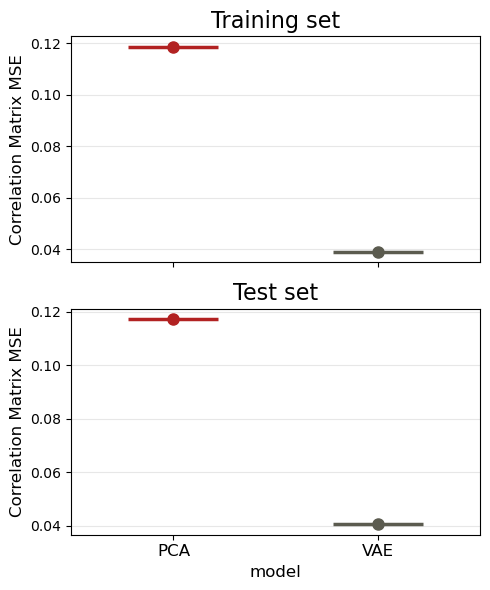

In [27]:
# %%
import matplotlib.pyplot as plt

color_map = {"PCA": "#b22222", "VAE": "#5b5b4f"}

fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex=True)

for ax, split in zip(axes, ["Training set", "Test set"]):
    sub = summary_df[summary_df["dataset"] == split].copy()
    x_positions = {"PCA": 0, "VAE": 1}

    for _, row in sub.iterrows():
        x = x_positions[row["model"]]
        y = row["mean_correlation_mse"]
        yerr = row["sd_correlation_mse"]
        color = color_map[row["model"]]

        ax.errorbar(
            x, y,
            yerr=yerr if not np.isnan(yerr) else 0,
            fmt="o",
            color=color,
            elinewidth=2,
            capsize=5,
            markersize=8
        )
        ax.hlines(y, x - 0.22, x + 0.22, color=color, linewidth=2.5)

    ax.set_title(split, fontsize=16)
    ax.set_ylabel("Correlation Matrix MSE", fontsize=12)
    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["PCA", "VAE"], fontsize=12)
    ax.grid(axis="y", alpha=0.3)

axes[1].set_xlabel("model", fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
# %%
import os
import numpy as np
import pandas as pd
import shap
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr




In [30]:
# %%
# Returns only latent means (mu), shape = (n_samples, LATENT_DIM)
def predict_mu(x):
    x = np.asarray(x).astype("float32")
    return encoder.predict(x, verbose=0)[0]

# Quick test
mu_test = predict_mu(X_val[:5])
print("mu_test shape:", mu_test.shape)

mu_test shape: (5, 16)


In [31]:
# %%
# Small pilot first for speed
background_summary = shap.kmeans(X_train[:100], 15)

explainer = shap.KernelExplainer(predict_mu, background_summary)

test_subset = X_val[:25].astype("float32")
shap_values = explainer.shap_values(test_subset, nsamples=100)

print(f"Type of shap_values: {type(shap_values)}")
print(f"Shape of shap_values: {np.array(shap_values).shape}")
print(f"Shape of test_subset: {test_subset.shape}")

/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
  0%|          | 0/25 [00:00<?, ?it/s]/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/shap/explainers/_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together

Type of shap_values: <class 'numpy.ndarray'>
Shape of shap_values: (25, 1000, 16)
Shape of test_subset: (25, 1000)


In [32]:
# %%
def get_top_genes(shap_vals_for_dim, feature_names, top_n=10):
    """
    shap_vals_for_dim: array of shape (n_samples, n_features)
    """
    importance = np.abs(shap_vals_for_dim).mean(axis=0)
    top_indices = np.argsort(importance)[-top_n:][::-1]

    summary_table = pd.DataFrame({
        "gene": [feature_names[i] for i in top_indices],
        "SHAP_Importance": importance[top_indices]
    })

    return summary_table

In [33]:
# %%
def get_top_genes(shap_vals_for_dim, feature_names, top_n=10):
    """
    shap_vals_for_dim: array of shape (n_samples, n_features)
    """
    importance = np.abs(shap_vals_for_dim).mean(axis=0)
    top_indices = np.argsort(importance)[-top_n:][::-1]

    summary_table = pd.DataFrame({
        "gene": [feature_names[i] for i in top_indices],
        "SHAP_Importance": importance[top_indices]
    })

    return summary_table

In [34]:
# %%
latent_means = predict_mu(X_val)

n_latent = latent_means.shape[1]
latent_cols = [f"LD{i+1}" for i in range(n_latent)]

df_latent = pd.DataFrame(latent_means, columns=latent_cols, index=obs_val.index)

# Derive AD / NC from sample_id if not already present
if "condition" not in obs_val.columns:
    obs_val["condition"] = obs_val["sample_id"].str.extract(r"(ad|nc)", expand=False).str.upper()

df_latent["condition"] = obs_val["condition"].values

print("latent_means shape:", latent_means.shape)
print(df_latent.head())
print(df_latent["condition"].value_counts(dropna=False))

latent_means shape: (35879, 16)
                                         LD1       LD2       LD3       LD4  \
gsm4775574_nc7_AGAGAGCAGTAGATCA-1   0.883653 -0.068003  1.591581  0.117686   
gsm4775567_ad9_GACCCTTCAGTGTGCC-1   0.380121  0.450348 -2.075793 -1.774798   
gsm4775573_nc3_AAGCCATGTTCGAAGG-1  -1.339900  0.984631  0.233030 -0.054753   
gsm4775567_ad9_CCACTTGAGGATTACA-1  -1.412137  1.085740 -0.138337 -1.909516   
gsm4775571_ad20_ACTGCAAGTCAGCGTC-1 -0.637957  0.641714 -0.789172  0.080428   

                                         LD5       LD6       LD7       LD8  \
gsm4775574_nc7_AGAGAGCAGTAGATCA-1  -0.299133 -0.196979 -0.765059 -1.964204   
gsm4775567_ad9_GACCCTTCAGTGTGCC-1   0.746790  0.678983 -0.212750 -1.426403   
gsm4775573_nc3_AAGCCATGTTCGAAGG-1  -0.337790  0.092461 -0.968525 -0.686744   
gsm4775567_ad9_CCACTTGAGGATTACA-1  -0.376869  0.168712  0.525739 -0.364332   
gsm4775571_ad20_ACTGCAAGTCAGCGTC-1 -1.009611  0.765430  0.367709  0.122317   

                              

In [35]:
# %%
latent_means = predict_mu(X_val)

latent_cols = [f"LD{i+1}" for i in range(latent_means.shape[1])]
df_latent = pd.DataFrame(latent_means, columns=latent_cols, index=obs_val.index)

# Derive AD / NC from sample_id if not already present
if "condition" not in obs_val.columns:
    obs_val["condition"] = obs_val["sample_id"].str.extract(r"(ad|nc)", expand=False).str.upper()

df_latent["condition"] = obs_val["condition"].values

print(df_latent.head())
print(df_latent["condition"].value_counts(dropna=False))

                                         LD1       LD2       LD3       LD4  \
gsm4775574_nc7_AGAGAGCAGTAGATCA-1   0.883653 -0.068003  1.591581  0.117686   
gsm4775567_ad9_GACCCTTCAGTGTGCC-1   0.380121  0.450348 -2.075793 -1.774798   
gsm4775573_nc3_AAGCCATGTTCGAAGG-1  -1.339900  0.984631  0.233030 -0.054753   
gsm4775567_ad9_CCACTTGAGGATTACA-1  -1.412137  1.085740 -0.138337 -1.909516   
gsm4775571_ad20_ACTGCAAGTCAGCGTC-1 -0.637957  0.641714 -0.789172  0.080428   

                                         LD5       LD6       LD7       LD8  \
gsm4775574_nc7_AGAGAGCAGTAGATCA-1  -0.299133 -0.196979 -0.765059 -1.964204   
gsm4775567_ad9_GACCCTTCAGTGTGCC-1   0.746790  0.678983 -0.212750 -1.426403   
gsm4775573_nc3_AAGCCATGTTCGAAGG-1  -0.337790  0.092461 -0.968525 -0.686744   
gsm4775567_ad9_CCACTTGAGGATTACA-1  -0.376869  0.168712  0.525739 -0.364332   
gsm4775571_ad20_ACTGCAAGTCAGCGTC-1 -1.009611  0.765430  0.367709  0.122317   

                                         LD9      LD10      LD

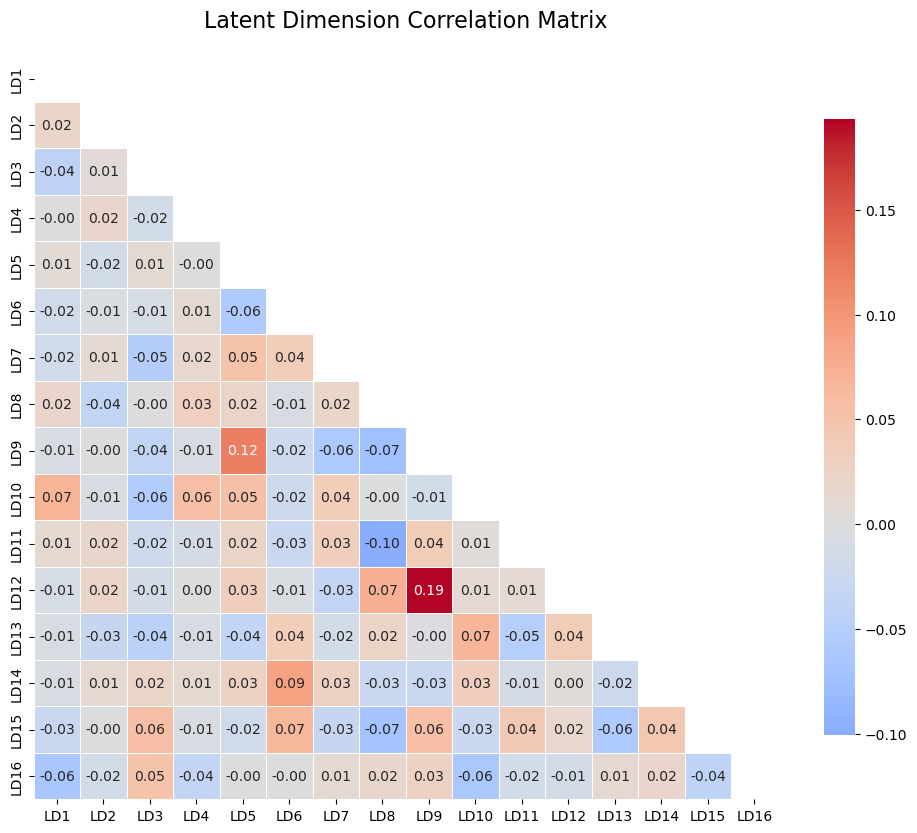

In [36]:
# %%
corr_matrix = df_latent[latent_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Latent Dimension Correlation Matrix", fontsize=16, pad=20)
plt.show()

In [37]:
# %%
def disease_latent_correlation():
    is_ad = (df_latent["condition"].values == "AD").astype(int)

    correlations = {}
    for col in latent_cols:
        r_val, p_val = pearsonr(df_latent[col], is_ad)
        correlations[col] = (r_val, p_val)

    sorted_corrs = sorted(correlations.items(), key=lambda x: abs(x[1][0]), reverse=True)

    print(f"{'Dimension':<12} | {'Corr':<8} | {'P-Value':<10} | {'Significance'}")
    print("-" * 55)

    for ld, (corr, p_val) in sorted_corrs[:10]:
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"{ld:<12} | {corr:<8.4f} | {p_val:<10.2e} | {sig}")

    return sorted_corrs

sorted_corrs = disease_latent_correlation()

Dimension    | Corr     | P-Value    | Significance
-------------------------------------------------------
LD5          | 0.1055   | 2.69e-89   | ***
LD16         | 0.1033   | 1.17e-85   | ***
LD13         | -0.0948  | 2.32e-72   | ***
LD12         | -0.0500  | 2.69e-21   | ***
LD3          | -0.0468  | 7.60e-19   | ***
LD2          | 0.0434   | 1.89e-16   | ***
LD8          | -0.0390  | 1.45e-13   | ***
LD9          | 0.0195   | 2.13e-04   | ***
LD14         | 0.0186   | 4.25e-04   | ***
LD10         | -0.0178  | 7.24e-04   | ***


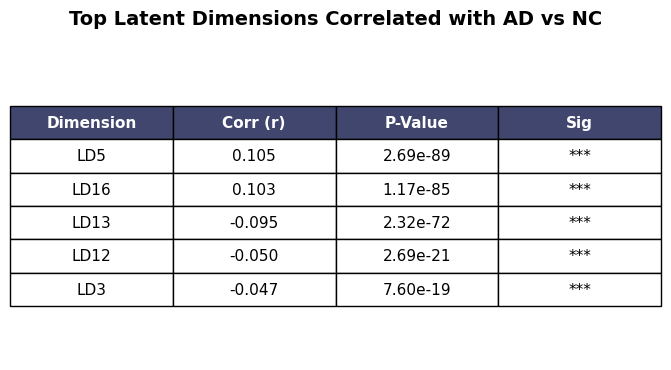

In [38]:
# %%
def plot_ad_table(top_n=5):
    is_ad = (df_latent["condition"].values == "AD").astype(int)

    data_for_table = []
    for col in latent_cols:
        r, p = pearsonr(df_latent[col], is_ad)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        data_for_table.append([col, r, p, sig])

    data_for_table.sort(key=lambda x: abs(x[1]), reverse=True)
    top_rows = data_for_table[:top_n]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.axis("off")
    ax.set_title("Top Latent Dimensions Correlated with AD vs NC", fontsize=14, weight="bold", pad=20)

    table = ax.table(
        cellText=[[row[0], f"{row[1]:.3f}", f"{row[2]:.2e}", row[3]] for row in top_rows],
        colLabels=["Dimension", "Corr (r)", "P-Value", "Sig"],
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.0)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#40466e")

    plt.show()

plot_ad_table(top_n=5)

In [39]:
# %%
top_dims = [int(ld.replace("LD", "")) - 1 for ld, _ in [(sorted_corrs[0][0], sorted_corrs[0][1]), (sorted_corrs[1][0], sorted_corrs[1][1])]]

dim_1, dim_2 = top_dims[0], top_dims[1]
print("dim_1 =", dim_1)
print("dim_2 =", dim_2)

dim_1 = 4
dim_2 = 15


In [40]:
# %%
# shap_values shape expected: (n_samples, n_features, n_outputs)
# We want: (n_outputs, n_samples, n_features)
shap_values_T = np.transpose(shap_values, (2, 0, 1))
print("shap_values_T shape:", shap_values_T.shape)

shap_values_T shape: (16, 25, 1000)


In [48]:
import anndata as ad
import os

adata_combined = ad.read_h5ad(os.path.join(OUT_DIR, "GSE157827_combined.h5ad"))

adata_vae_tmp, _ = preprocess_for_vae(
    adata_combined,
    use_hvg=USE_HVG,
    n_top_genes=N_TOP_GENES,
    min_cells_per_gene=MIN_CELLS_PER_GENE,
    target_sum=TARGET_SUM,
)

feature_names = adata_vae_tmp.var_names.to_list()

print("Recovered feature count:", len(feature_names))
print("X_train columns:", X_train.shape[1])

/opt/miniconda3/envs/vae_env/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Recovered feature count: 1000
X_train columns: 1000


/var/folders/5d/yz69blqn7m7b2l4x7j0ns7z00000gn/T/ipykernel_7431/1983255341.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/var/folders/5d/yz69blqn7m7b2l4x7j0ns7z00000gn/T/ipykernel_7431/1983255341.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


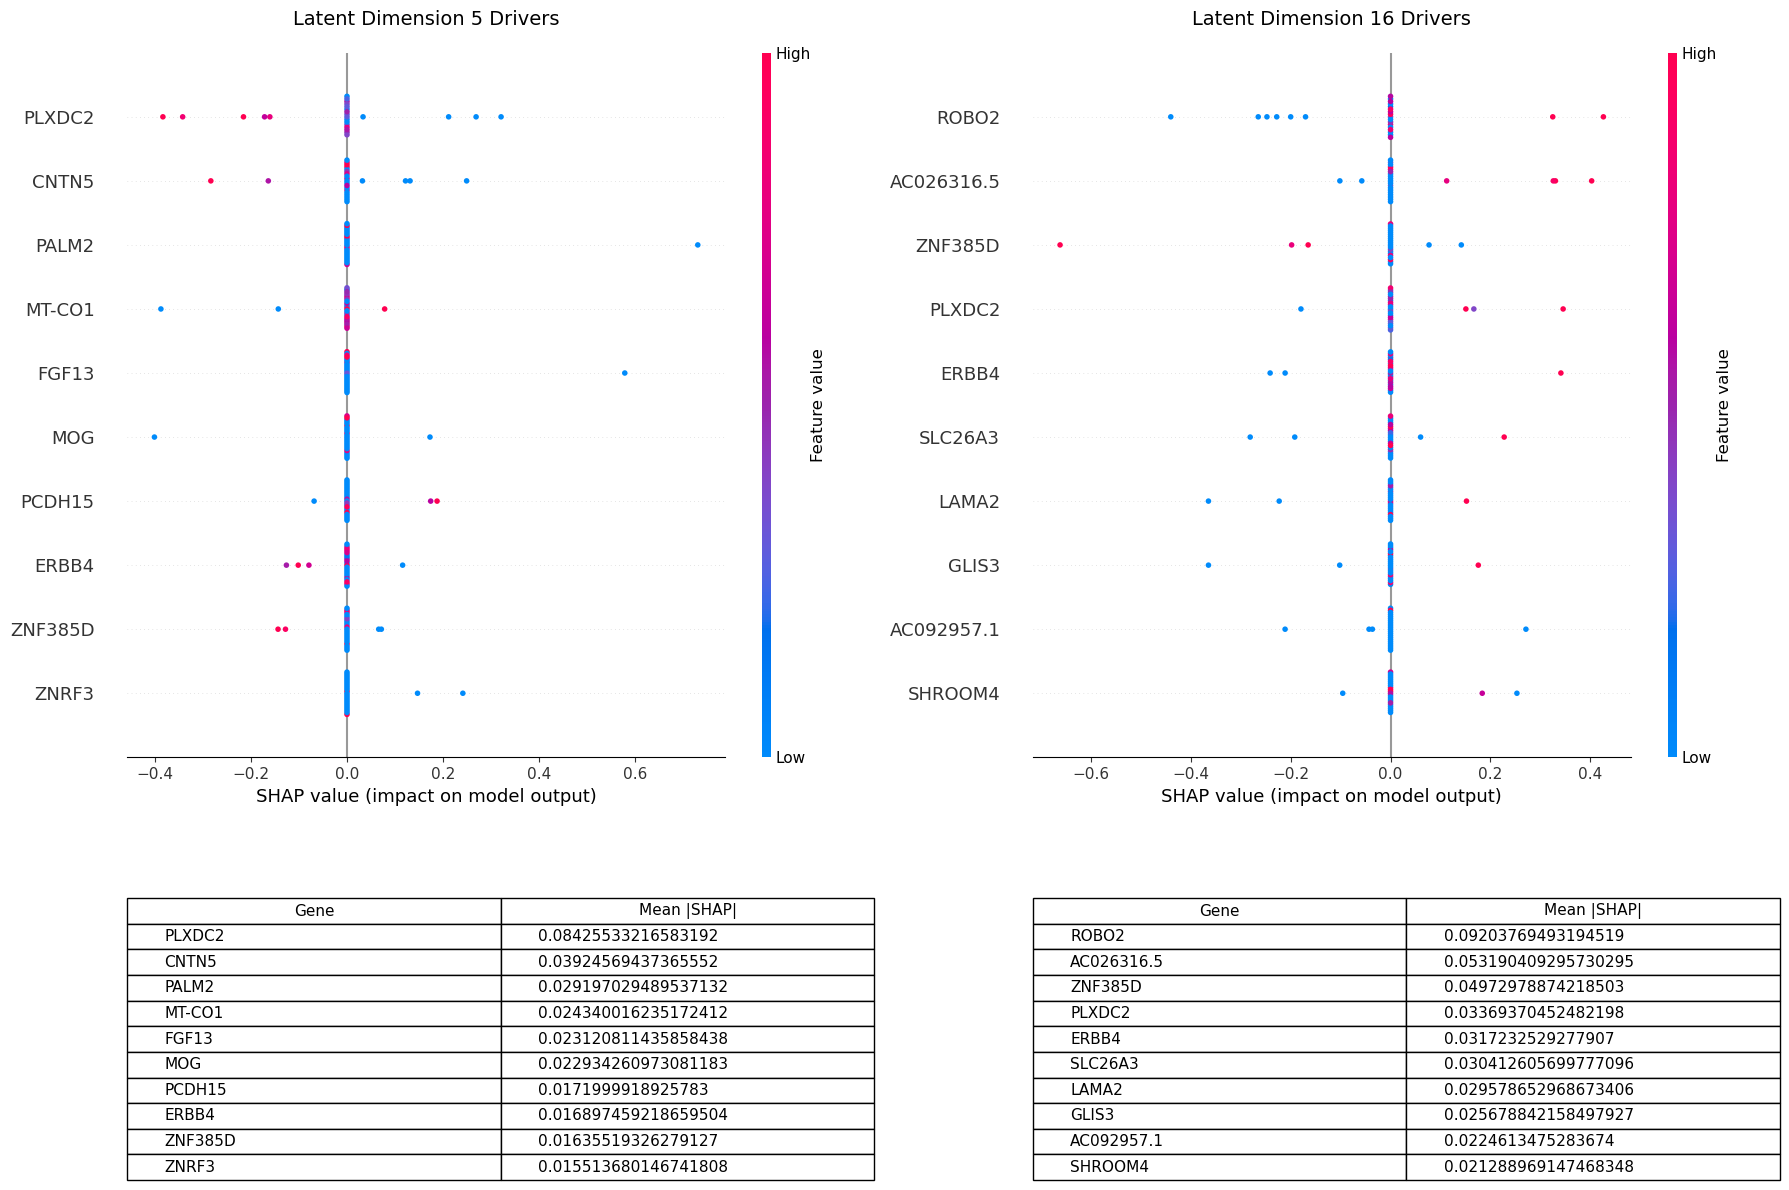

In [49]:
# %%
def shap_with_table(latent_dim, gs_slot):
    inner_grid = gs_slot.subgridspec(2, 1, height_ratios=[3, 1], hspace=0.4)
    ax_shap = fig.add_subplot(inner_grid[0])
    ax_table = fig.add_subplot(inner_grid[1])

    # SHAP beeswarm
    plt.sca(ax_shap)
    shap.summary_plot(
        shap_values_T[latent_dim],
        test_subset,
        feature_names=feature_names,
        max_display=10,
        show=False,
        plot_size=None
    )
    ax_shap.set_title(f"Latent Dimension {latent_dim+1} Drivers", fontsize=14, pad=20)

    # Top genes table
    top_data = get_top_genes(shap_values_T[latent_dim], feature_names, top_n=10)
    table_data = top_data.reset_index(drop=True).values

    ax_table.axis("off")
    tbl = ax_table.table(
        cellText=table_data,
        colLabels=["Gene", "Mean |SHAP|"],
        loc="center",
        cellLoc="left",
        bbox=[0.0, 0, 1.0, 1.2]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(1, 2)

shap_with_table(dim_1, gs[0])
shap_with_table(dim_2, gs[1])

plt.tight_layout()
plt.show()

In [50]:
# %%
SHAP_DIR = os.path.join(OUT_DIR, "shap_values")
os.makedirs(SHAP_DIR, exist_ok=True)

for dim in [dim_1, dim_2]:
    top_df = get_top_genes(shap_values_T[dim], feature_names, top_n=20)
    top_df.to_csv(os.path.join(SHAP_DIR, f"top_genes_shap_dim_{dim+1}.csv"), index=False)

print("Saved top-gene SHAP tables.")

Saved top-gene SHAP tables.
